In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

<H1>Part One: Load Data</H1>

In [52]:
# Load data
df = pd.read_csv("gaming_difficulty_retention.csv")

In [53]:
# Feature variables
X = df[["difficulty", "total_playtime_hours", "sessions_played", "completion_status"]]

# Target variable 
y = df["retained_7days"]

<H1>Part Two: Cleaning Data</H1>

In [54]:
X.isnull().sum()

difficulty              0
total_playtime_hours    0
sessions_played         0
completion_status       0
dtype: int64

In [55]:
df.dtypes

player_id                      int64
difficulty                    object
total_playtime_hours         float64
sessions_played                int64
retained_7days                 int64
retained_30days                int64
completion_status              int64
Retention Status (7-day)      object
Retention Status (30-day)     object
Playtime                      object
dtype: object

In [56]:
df.isnull().sum()

player_id                    0
difficulty                   0
total_playtime_hours         0
sessions_played              0
retained_7days               0
retained_30days              0
completion_status            0
Retention Status (7-day)     0
Retention Status (30-day)    0
Playtime                     0
dtype: int64

<H1>Part Three: Preprocessing </H1>

In [57]:
# Preprocessing
numeric_features = ["total_playtime_hours", "sessions_played", "completion_status"]
categorical_features = ["difficulty"]

In [58]:
# Using median imputation so that missing values get filled with the median of that column, so that we don't lose rows.
# Categorical column (difficulty) uses most frequent imputation, filling the missing values with the most common difficulty.
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

In [59]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [60]:
# Logistic Regression model
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION")
print("Accuracy:", accuracy_score(y_test, log_preds))
print("ROC-AUC:", roc_auc_score(y_test, log_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, log_preds))
print("Classification Report:\n", classification_report(y_test, log_preds))

LOGISTIC REGRESSION
Accuracy: 0.73
ROC-AUC: 0.7472410865874363
Confusion Matrix:
 [[27 11]
 [16 46]]
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.71      0.67        38
           1       0.81      0.74      0.77        62

    accuracy                           0.73       100
   macro avg       0.72      0.73      0.72       100
weighted avg       0.74      0.73      0.73       100



In [61]:
# Random Forest model
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_preds))
print("Classification Report:\n", classification_report(y_test, rf_preds))

RANDOM FOREST
Accuracy: 0.65
ROC-AUC: 0.7319609507640068
Confusion Matrix:
 [[20 18]
 [17 45]]
Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.53      0.53        38
           1       0.71      0.73      0.72        62

    accuracy                           0.65       100
   macro avg       0.63      0.63      0.63       100
weighted avg       0.65      0.65      0.65       100



In [62]:
# Gradient Boosting model
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)
gb_probs = gb_model.predict_proba(X_test)[:, 1]

print("GRADIENT BOOSTING")
print("Accuracy:", accuracy_score(y_test, gb_preds))
print("ROC-AUC:", roc_auc_score(y_test, gb_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, gb_preds))
print("Classification Report:\n", classification_report(y_test, gb_preds))

GRADIENT BOOSTING
Accuracy: 0.73
ROC-AUC: 0.7289898132427844
Confusion Matrix:
 [[25 13]
 [14 48]]
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.66      0.65        38
           1       0.79      0.77      0.78        62

    accuracy                           0.73       100
   macro avg       0.71      0.72      0.71       100
weighted avg       0.73      0.73      0.73       100



In [70]:
# Compare all three models
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, log_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, gb_preds)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, gb_probs)
    ]
})

results.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.73,0.747241
1,Random Forest,0.65,0.731961
2,Gradient Boosting,0.73,0.728990


In [71]:
cm = confusion_matrix(y_test, log_preds)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, log_preds))

Confusion Matrix:
[[27 11]
 [16 46]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.71      0.67        38
           1       0.81      0.74      0.77        62

    accuracy                           0.73       100
   macro avg       0.72      0.73      0.72       100
weighted avg       0.74      0.73      0.73       100



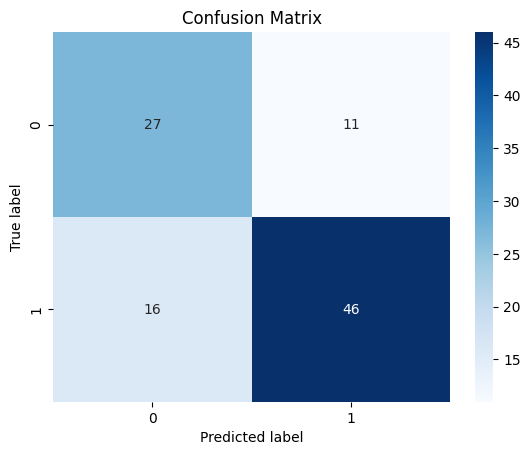

In [65]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

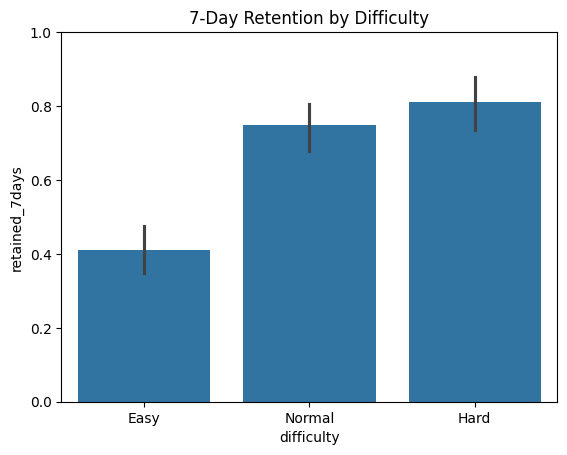

In [67]:
# Plot 1: Retention by difficulty
sns.barplot(data=df, x="difficulty", y="retained_7days", order=["Easy", "Normal", "Hard"])
plt.title("7-Day Retention by Difficulty")
plt.ylim(0, 1)
plt.show()

# 0 being players not retained at 7 days, 1 being players retained at 7 days


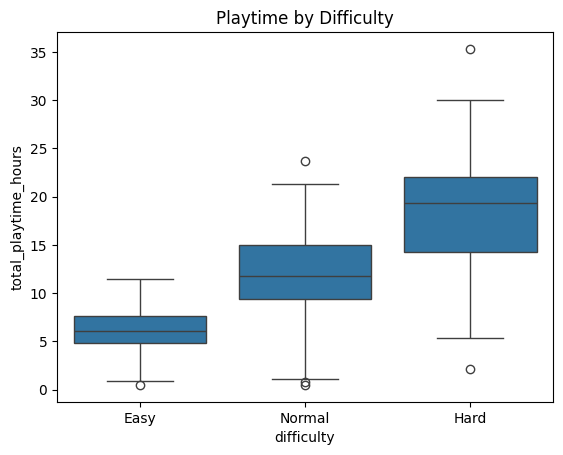

In [68]:
# Plot 2: Playtime by difficulty
sns.boxplot(data=df, x="difficulty", y="total_playtime_hours", order=["Easy", "Normal", "Hard"])
plt.title("Playtime by Difficulty")
plt.show()

# This graph tells us how long players stick with each difficulty level. 
# If players who choose "Hard" have significantly higher playtime, it may indicate that they are more engaged and likely to be retained.

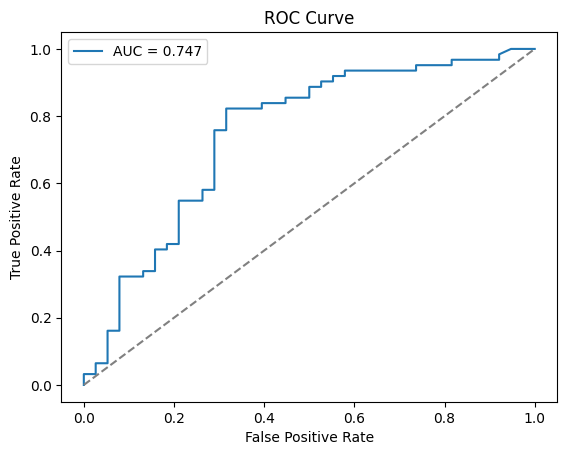

In [69]:
# Plot 3: ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

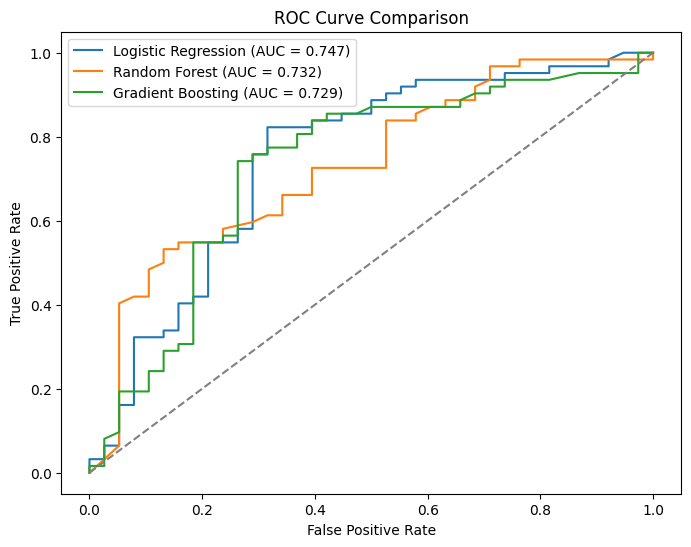

In [73]:
# ROC curves for all models
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probs)

plt.figure(figsize=(8, 6))
plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, log_probs):.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.3f})")
plt.plot(gb_fpr, gb_tpr, label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, gb_probs):.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()